# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [8]:
# Import necessary libraries 🔧
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('/content/listings.csv.gz')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4199 entries, 0 to 4198
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4199 non-null   int64  
 1   listing_url                                   4199 non-null   object 
 2   scrape_id                                     4199 non-null   int64  
 3   last_scraped                                  4199 non-null   object 
 4   source                                        4199 non-null   object 
 5   name                                          4199 non-null   object 
 6   description                                   4134 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   4199 non-null   object 
 9   host_id                                       4199 non-null   i

## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Columns with missing values:


,Missing Count,Percentage (%)
neighborhood_overview,4199,100.000000
host_since,4199,100.000000
host_total_listings_count,4199,100.000000
neighbourhood,4199,100.000000
host_verifications,4199,100.000000
host_response_rate,4199,100.000000
host_acceptance_rate,4199,100.000000
host_thumbnail_url,4199,100.000000
host_response_time,4199,100.000000
host_neighbourhood,4199,100.000000


/tmp/ipykernel_516/1260953.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Percentage (%)'], palette='viridis')


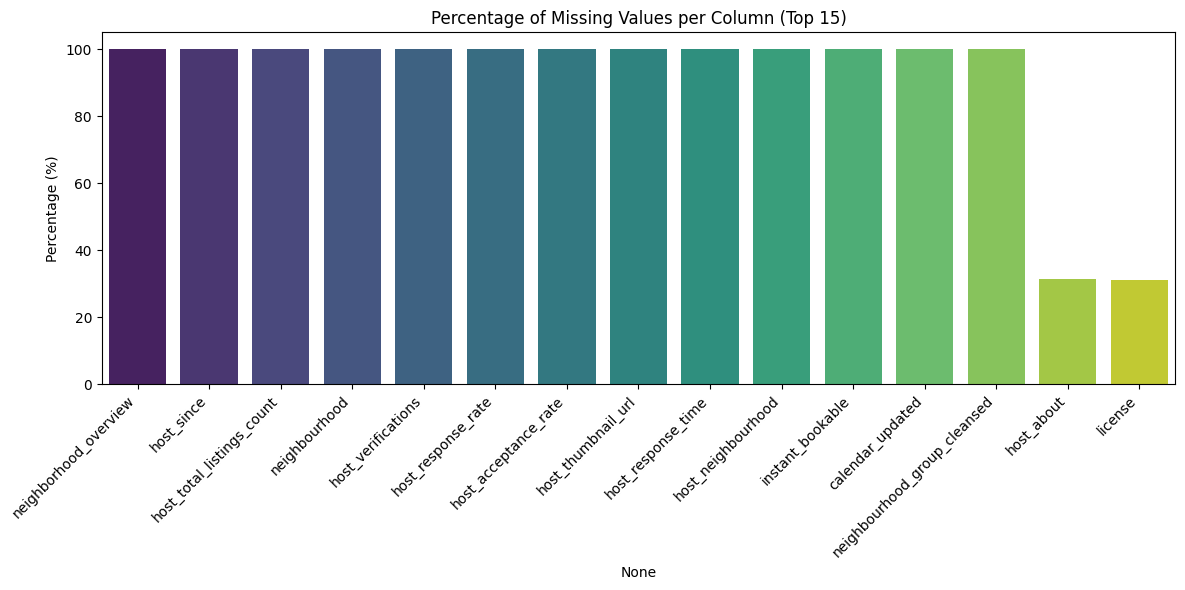

In [9]:
# Calculate missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("Columns with missing values:")
display(missing_df.head(20))

# Visualize missing values using a bar plot for the top missing columns
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Percentage (%)'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Percentage of Missing Values per Column (Top 15)')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1.The top 3 columns with missing values are the host thumbnail url, the host repsonse rate and neighborhood overview.

2. I think the ones out of the missing columns that are likly to create business issues are the host acceptance rate, calendar updated and neighborhood. These are important to understanding the data for Airbnb listings for this city. They would help us get a much better idea of the listings we are looking at as well as if hosts are responding to clients.

3. I think columns that could safely be ignored are the host thumbnail url, neighborhood group cleansed, and host since. These don't really seem necesary to analyzing Airbnb listings, and I would consider them irrelevent.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [10]:
# Drop irrelevant columns identified by the user
columns_to_drop = ['host_thumbnail_url', 'neighbourhood_group_cleansed']
# Use errors='ignore' in case columns are already dropped or slightly different in spelling
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# Confirm they are gone
print("Remaining columns (first 10):", list(df_cleaned.columns[:10]))
print(f"Are dropped columns still in dataframe? {'host_thumbnail_url' in df_cleaned.columns or 'neighbourhood_group_cleansed' in df_cleaned.columns}")
display(df_cleaned.head())

Remaining columns (first 10): ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']
Are dropped columns still in dataframe? False


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,37676,https://www.airbnb.com/rooms/37676,20260615054150,2026-06-15,city scrape,Mt. Hood View in the Pearl District,"This rare and relaxing 1,000 SF loft is locate...",NaN,https://a0.muscache.com/pictures/212298/16fb6b...,162158,...,4.79,4.95,4.69,NaN,NaN,2,2,0,0,0.70
1,61893,https://www.airbnb.com/rooms/61893,20260615054150,2026-06-15,city scrape,Perfect Portland Place,Amazing for a long stay in<br />Portland's per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,300391,...,5.00,5.00,4.92,NaN,NaN,1,1,0,0,0.22
2,67036,https://www.airbnb.com/rooms/67036,20260615054150,2026-06-15,city scrape,Historic Home Located in Central City,"Welcome to Multnomah House, a classic Portland...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,329777,...,4.98,4.82,4.84,12-123170-000-00-LU,NaN,1,1,0,0,0.48
3,93613,https://www.airbnb.com/rooms/93613,20260615054150,2026-06-15,city scrape,Sunny Queen Room in FUN Alberta Arts,Peaceful home in vibrant Alberta Arts neighbor...,NaN,https://a0.muscache.com/pictures/9f0226fd-b39f...,501715,...,4.75,4.85,4.46,NaN,NaN,10,3,7,0,0.40
4,99355,https://www.airbnb.com/rooms/99355,20260615054150,2026-06-15,city scrape,Beautiful Apt near City Center!,A beautiful 1908 Craftsman home in a historic ...,NaN,https://a0.muscache.com/pictures/79983a33-e01c...,523311,...,4.97,4.95,4.84,08-175882-000-00-LU,NaN,2,2,0,0,2.02


### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped the columns host_thumbnail_url and neighbourhood_group_cleansed.

2. They aren't useful from a business perspective because host_thumbnail_url only stores links to small profile pictures which do not contribute to financial, pricing, or trend analysis. Neighbourhood_group_cleansed was completely empty (100% missing values) because this city does not use higher-level borough/neighborhood groupings, making it useless for geographic segmentation.

3. Leaving them in would clutter the dataset, increase memory usage, and could confuse other analysts or business dashboards trying to query columns that contain either entirely blank values or useless web links.

## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [11]:
# 1. Fill missing review scores with the median score
median_rating = df_cleaned['review_scores_rating'].median()
df_cleaned['review_scores_rating'] = df_cleaned['review_scores_rating'].fillna(median_rating)

# 2. Fill missing host names with 'Unknown'
df_cleaned['host_name'] = df_cleaned['host_name'].fillna('Unknown')

# Verify changes
print(f"Missing values in 'review_scores_rating': {df_cleaned['review_scores_rating'].isnull().sum()}")
print(f"Missing values in 'host_name': {df_cleaned['host_name'].isnull().sum()}")

Missing values in 'review_scores_rating': 0
Missing values in 'host_name': 0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. The two coulumns I cleaned were the review scores rating and host name.

2. For the review score, I filled it with the mediam review score for the dataset. I did this becuase its a numeric value and thought the median would not disrupt the rest of the data analysis. For the host name, I input the "Uknown" into that column if it was missing a value which helps clarify for someone looking at the data why there is no value there.

3.  Using the median rating assumes that listings without reviews would have been rated average. In reality, a listing might lack reviews because it is brand new. This can artificially inflate the perceived quality of unrated listings. In addition, replacing missing names with 'Unknown' prevents database errors, but it strips away identity. If a guest needs to contact their host in an emergency, having 'Unknown' in the system poses trust risks.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

In [13]:
# 1. Inspect the unique values/type first (e.g., $150.00)
print("Original Price data type:", df_cleaned['price'].dtype)
print("Sample price values:", df_cleaned['price'].head())

# 2. Strip '$' and ',' and convert to numeric float
df_cleaned['price'] = df_cleaned['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_cleaned['price'] = pd.to_numeric(df_cleaned['price'], errors='coerce')

print("New Price data type:", df_cleaned['price'].dtype)
print(df_cleaned['price'].describe())

Original Price data type: float64
Sample price values: 0    116.52
1     93.14
2    556.50
3     43.18
4    377.00
Name: price, dtype: float64
New Price data type: float64
count    3635.000000
mean      204.087857
std       163.831646
min         7.050000
25%       111.145000
50%       160.000000
75%       237.180000
max      2765.470000
Name: price, dtype: float64


### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the price column.

2. The cleaning steps I applied were stripping out formatting symbols like the dollar sign and commas. I also converted the resulting clean string values back into numeric float types.

3. This prepares the data for later use because the text cannot be used in statistical calculations. Converting the price to a numeric type allows us to perform mathematical operations which will later let us plot the data better.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [15]:
exact_duplicates = df_cleaned.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates}")

# 2. Check for duplicate listing IDs
duplicate_ids = df_cleaned.duplicated(subset=['id']).sum()
print(f"Number of duplicate listing IDs: {duplicate_ids}")

# 3. Remove duplicate records if they exist, keeping the first occurrence
if duplicate_ids > 0:
    df_cleaned = df_cleaned.drop_duplicates(subset=['id'], keep='first')
    print("Duplicate listing IDs have been successfully removed, keeping the original record.")
else:
    print("No duplicate records found")

Number of exact duplicate rows: 0
Number of duplicate listing IDs: 0
No duplicate records found. The dataset is clean!


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No, I did not find any exact duplicate rows or duplicate listing IDs in this dataset.

2. I wrote logic to check for unique values in the ID column. If duplicate listing IDs had been found, the strategy was to drop the subsequent records and keep the first listing.

3. Duplicates are highly risky because they can artifically inflate the dataset. For guests, showing duplicate listings can lead to double-booking issues and diminish trust in the platform.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [20]:
# Export the cleaned DataFrame to a CSV file
df_cleaned.to_csv('cleaned_airbnb_data_6.csv', index=False)


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. I think for me, the most challenging section was thinking about what columns to delete. It felt like deleting a whole column was a big deal, but then I had to remember that this would make the data easier to work with.

2.  It was critical to drop host_thumbnail_url and neighbourhood_group_cleansed because they were entirely irrelevant to analysis, and they were both 100% missing. Keeping these columns would have cluttered database operations and slowed down computation without adding analytic value.

3. Pricing analysts and hosts benefit immensely because the price and rating columns are now consistently typed and populated. This enables them to build reliable pricing models and predictive dashboards without running into issues caused by missing fields.

4. If I had more time, I would explore the relationships between host response rates and final reviews to identify key indicators of customer satisfaction.

5. This hands-on cleaning process directly aligns with my goal becuase it allows me to present simple, clean data to customers in an accurate way.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [23]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_06_data_cleaning.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru